In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
print ("done")

done


In [2]:
df = pd.read_csv('online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
df['CustomerID'] = df['CustomerID'].fillna('Guest')

df = df.dropna(subset=['Description'])

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [6]:
print("Negative Quantity rows:", (df['Quantity'] < 0).sum())
print("Negative UnitPrice rows:", (df['UnitPrice'] < 0).sum())
print("Zero UnitPrice rows:", (df['UnitPrice'] == 0).sum())

Negative Quantity rows: 9762
Negative UnitPrice rows: 2
Zero UnitPrice rows: 1061


In [7]:
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,540455.000000,540455.000000
mean,9.603129,4.623519
std,218.007598,96.889628
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [8]:
df.sort_values('Quantity', ascending=False).head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom


In [9]:
df.sort_values('UnitPrice', ascending=False).head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,Guest,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,Guest,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,Guest,United Kingdom
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,Guest,United Kingdom


In [10]:
non_product_codes = ['POST', 'D', 'DOT', 'M', 'AMAZONFEE', 'BANK CHARGES', 'B', 'CRUK', 'C2']
df_clean = df[~df['StockCode'].isin(non_product_codes)].copy()

In [11]:
print(df.shape)
print(df_clean.shape)
df_clean.sort_values('UnitPrice', ascending=False).head(5)

(540455, 8)
(537613, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.5,15098.0,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.5,15098.0,United Kingdom
242589,C558359,S,SAMPLES,-1,2011-06-28 15:10:00,570.0,Guest,United Kingdom
32484,539080,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-16 08:41:00,295.0,16607.0,United Kingdom
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02 18:06:00,295.0,13145.0,United Kingdom


In [12]:
df_clean['TotalRevenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['PurchaseHour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean[['InvoiceDate', 'PurchaseHour', 'DayOfWeek', 'YearMonth', 'TotalRevenue']].head()

,InvoiceDate,PurchaseHour,DayOfWeek,YearMonth,TotalRevenue
0,2010-12-01 08:26:00,8,Wednesday,2010-12,15.30
1,2010-12-01 08:26:00,8,Wednesday,2010-12,20.34
2,2010-12-01 08:26:00,8,Wednesday,2010-12,22.00
3,2010-12-01 08:26:00,8,Wednesday,2010-12,20.34
4,2010-12-01 08:26:00,8,Wednesday,2010-12,20.34


In [13]:
hourly_orders = df_clean.groupby('PurchaseHour') ['InvoiceNo'].count()
print(hourly_orders)

PurchaseHour
6        39
7       379
8      8840
9     34033
10    48555
11    57222
12    78164
13    71808
14    66927
15    76845
16    54101
17    28210
18     7926
19     3695
20      869
Name: InvoiceNo, dtype: int64


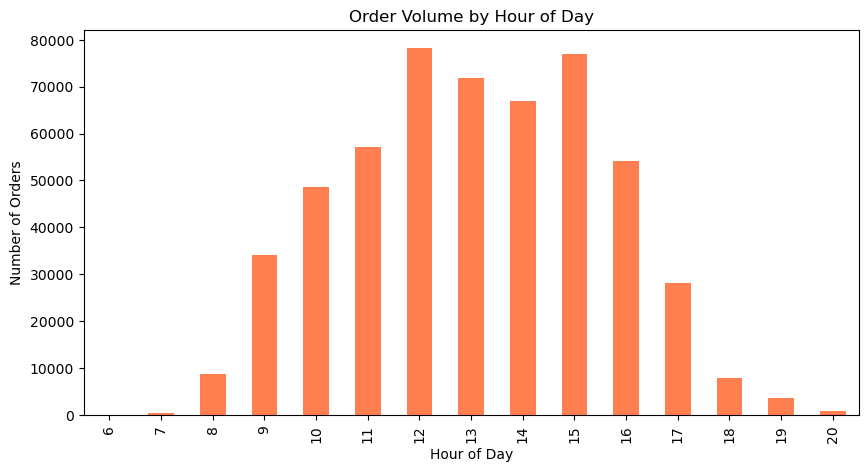

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
hourly_orders.plot(kind='bar', color='coral')
plt.title('Order Volume by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.show()

In [15]:
daily_orders = df_clean.groupby('DayOfWeek')['InvoiceNo'].count()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_orders = daily_orders.reindex(day_order)
print(daily_orders)

DayOfWeek
Monday        94344.0
Tuesday      100943.0
Wednesday     93772.0
Thursday     102999.0
Friday        81323.0
Saturday          NaN
Sunday        64232.0
Name: InvoiceNo, dtype: float64


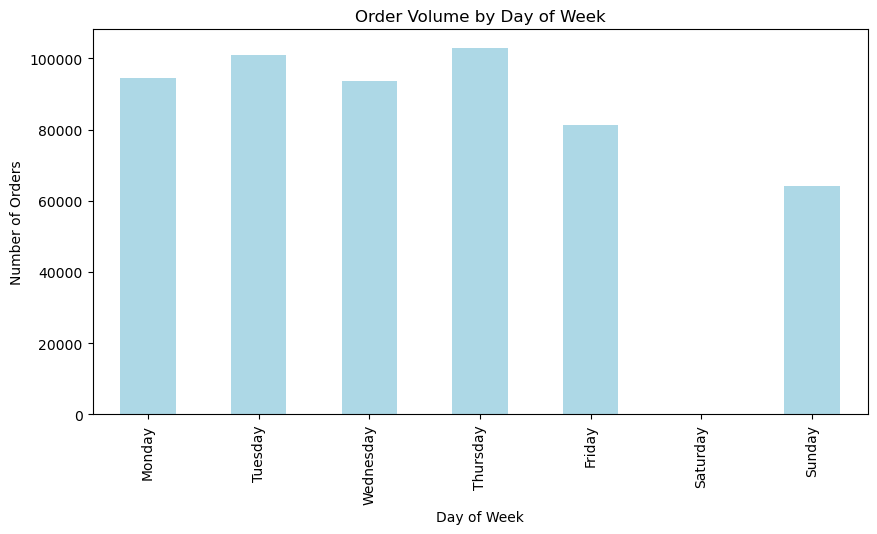

In [16]:
plt.figure(figsize=(10,5))
daily_orders.plot(kind='bar', color='lightblue')
plt.title('Order Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.show()

In [17]:
daily_orders

DayOfWeek
Monday        94344.0
Tuesday      100943.0
Wednesday     93772.0
Thursday     102999.0
Friday        81323.0
Saturday          NaN
Sunday        64232.0
Name: InvoiceNo, dtype: float64

In [18]:
monthly_revenue = df_clean.groupby('YearMonth')['TotalRevenue'].sum()
print(monthly_revenue)

YearMonth
2010-12     760338.100
2011-01     580466.110
2011-02     499758.580
2011-03     680473.800
2011-04     483022.881
2011-05     731907.960
2011-06     724490.530
2011-07     677988.531
2011-08     701876.440
2011-09    1013455.681
2011-10    1062543.290
2011-11    1432651.110
2011-12     441374.840
Freq: M, Name: TotalRevenue, dtype: float64


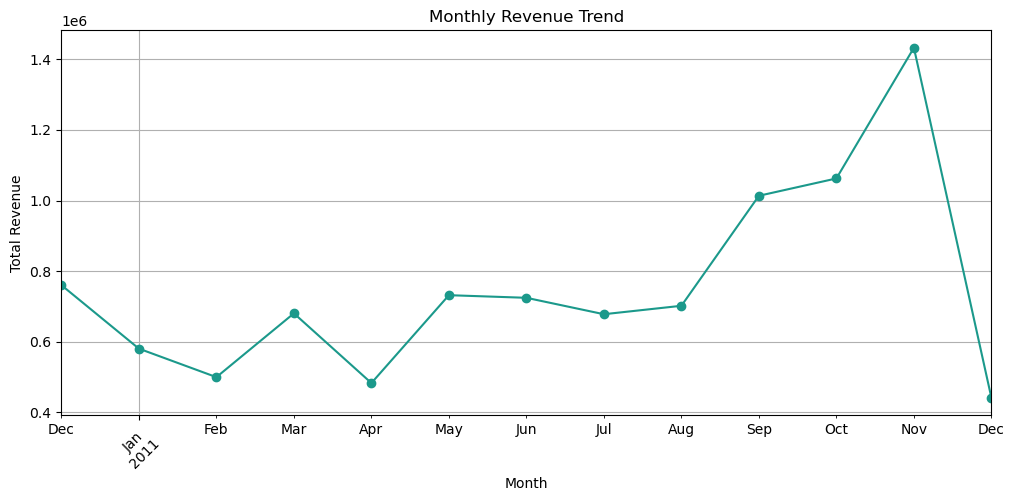

In [19]:
plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', marker='o', color='#1B998B')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [20]:
df_clean[df_clean['YearMonth'] == '2011-12']['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [21]:
df_trend = df_clean[df_clean['YearMonth'] != '2011-12']
monthly_revenue = df_trend.groupby('YearMonth')['TotalRevenue'].sum()

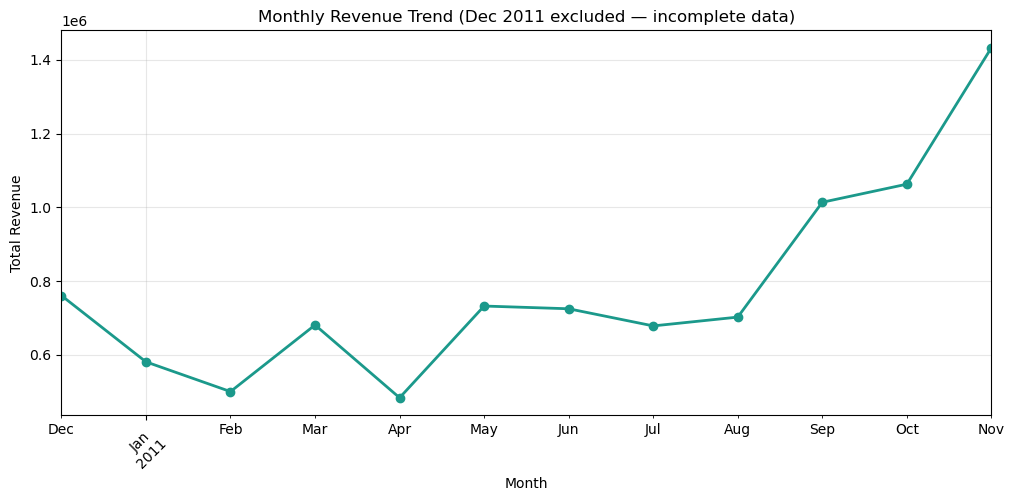

In [22]:
plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', marker='o', color='#1B998B', linewidth=2)
plt.title('Monthly Revenue Trend (Dec 2011 excluded — incomplete data)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
top_products = df_clean.groupby('Description')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
SPOTTY BUNTING                         42065.32
JUMBO BAG PINK POLKADOT                41619.66
Name: TotalRevenue, dtype: float64


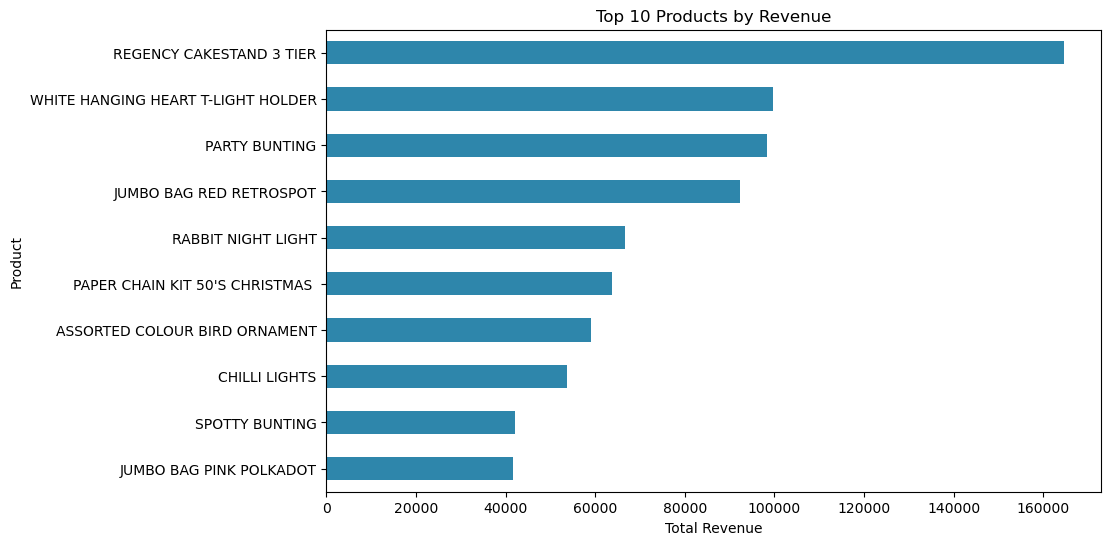

In [24]:
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.show()

In [25]:
worst_products = df_clean.groupby('Description')['TotalRevenue'].sum().sort_values(ascending=True).head(10)
print(worst_products)

Description
SAMPLES                           -3049.39
WHITE CHERRY LIGHTS                 -54.00
CREAM SWEETHEART MAGAZINE RACK      -46.85
WOODEN BOX ADVENT CALENDAR          -45.70
ASSORTED TUTTI FRUTTI ROUND BOX     -39.60
PINK CHERRY LIGHTS                  -27.00
BLUE PADDED SOFT MOBILE             -25.50
ANTIQUE LILY FAIRY LIGHTS           -14.85
CREAM SWEETHEART TRAYS              -12.75
TEA TIME CAKE STAND IN GIFT BOX     -10.75
Name: TotalRevenue, dtype: float64


In [26]:
top_frequency = df_clean.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
print(top_frequency)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2302
REGENCY CAKESTAND 3 TIER              2169
JUMBO BAG RED RETROSPOT               2135
PARTY BUNTING                         1706
LUNCH BAG RED RETROSPOT               1607
ASSORTED COLOUR BIRD ORNAMENT         1467
SET OF 3 CAKE TINS PANTRY DESIGN      1458
PACK OF 72 RETROSPOT CAKE CASES       1334
LUNCH BAG  BLACK SKULL.               1295
NATURAL SLATE HEART CHALKBOARD        1266
Name: InvoiceNo, dtype: int64


In [27]:
df_clean[df_clean['Description'] == 'SAMPLES'][['Quantity', 'UnitPrice', 'TotalRevenue']].head(20)

,Quantity,UnitPrice,TotalRevenue
14436,-1,12.95,-12.95
14437,-1,52.00,-52.00
96680,-1,5.74,-5.74
96681,-1,11.08,-11.08
96682,-1,5.79,-5.79
96683,-1,6.70,-6.70
96684,-1,8.74,-8.74
96685,-1,9.74,-9.74
96686,-1,9.99,-9.99
96687,-1,20.98,-20.98


In [28]:
print("Negative Quantity rows:", (df_clean['Quantity'] < 0).sum())

Negative Quantity rows: 9239


In [29]:
neg_qty = df_clean[df_clean['Quantity'] < 0]
print(neg_qty['InvoiceNo'].astype(str).str.startswith('C').mean())

0.9486957462928889


In [30]:
df_cancelled = df_clean[df_clean['Quantity'] < 0].copy()
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()

In [31]:
print("Negative Quantity rows:", (df_clean['Quantity'] < 0).sum())
print("New df_clean shape:", df_clean.shape)

Negative Quantity rows: 0
New df_clean shape: (527795, 12)


In [32]:
df_rfm_base = df_clean[df_clean['CustomerID'] != 'Guest'].copy()
print(df_rfm_base.shape)
print(df_rfm_base['CustomerID'].nunique())

(396340, 12)
4334


In [33]:
import datetime as dt
snapshot_date = df_rfm_base['InvoiceDate'].max() + dt.timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [34]:
rfm = df_rfm_base.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalRevenue': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(rfm.head())
print(rfm.shape)

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1437.24
12349.0          19          1   1457.55
12350.0         310          1    294.40
(4334, 3)


In [35]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
print(rfm.head())

            Recency  Frequency  Monetary R_Score F_Score M_Score
CustomerID                                                      
12346.0         326          1  77183.60       1       1       5
12347.0           2          7   4310.00       5       5       5
12348.0          75          4   1437.24       2       4       4
12349.0          19          1   1457.55       4       1       4
12350.0         310          1    294.40       1       1       2


In [36]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
print(rfm[['R_Score','F_Score','M_Score','RFM_Score']].head())

           R_Score F_Score M_Score RFM_Score
CustomerID                                  
12346.0          1       1       5       115
12347.0          5       5       5       555
12348.0          2       4       4       244
12349.0          4       1       4       414
12350.0          1       1       2       112


In [37]:
rfm['RFM_Total'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)
print(rfm.head())

            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
CustomerID                                                                   
12346.0         326          1  77183.60       1       1       5       115   
12347.0           2          7   4310.00       5       5       5       555   
12348.0          75          4   1437.24       2       4       4       244   
12349.0          19          1   1457.55       4       1       4       414   
12350.0         310          1    294.40       1       1       2       112   

            RFM_Total  
CustomerID             
12346.0             7  
12347.0            15  
12348.0            10  
12349.0             9  
12350.0             4  


In [38]:
def segment_customer(row):
    if row['RFM_Score'] in ['555','554','545','455','544','545','445','454']:
        return 'Champions'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
print(rfm['Segment'].value_counts())

Segment
Lost               1068
Others              860
Champions           839
At Risk             637
Loyal Customers     611
New Customers       319
Name: count, dtype: int64


In [39]:
rfm[rfm['Segment']=='Others'][['R_Score','F_Score','M_Score']].head(10)

,R_Score,F_Score,M_Score
CustomerID,,,
12352.0,3,5,4
12359.0,3,4,5
12360.0,3,3,5
12370.0,3,4,5
12371.0,3,1,4
12372.0,3,3,4
12393.0,3,4,4
12394.0,3,2,4
12397.0,3,2,5


In [40]:
def segment_customer(row):
    if row['RFM_Score'] in ['555','554','545','455','544','445','454']:
        return 'Champions'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] == 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] == 3:
        return 'Potential Loyalist'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
print(rfm['Segment'].value_counts())

Segment
Lost                  1068
Loyal Customers       1037
Champions              839
At Risk                637
Potential Loyalist     434
New Customers          319
Name: count, dtype: int64


In [41]:
total_revenue = rfm['Monetary'].sum()
champions_revenue = rfm[rfm['Segment']=='Champions']['Monetary'].sum()
print(f"Champions contribute {champions_revenue/total_revenue*100:.1f}% of total revenue")
print(f"Champions are {(rfm['Segment']=='Champions').sum()/len(rfm)*100:.1f}% of customers")

Champions contribute 63.5% of total revenue
Champions are 19.4% of customers


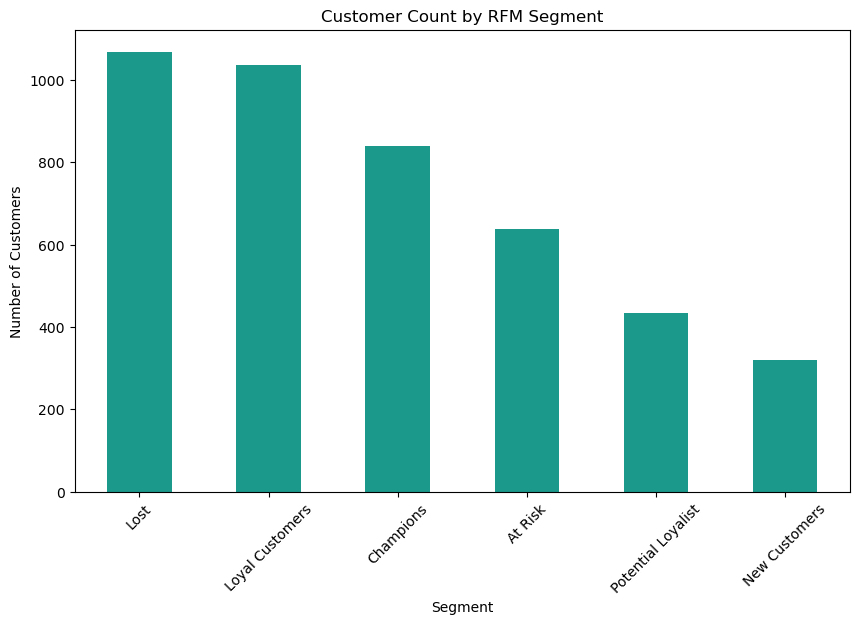

In [42]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,6))
segment_counts.plot(kind='bar', color='#1B998B')
plt.title('Customer Count by RFM Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

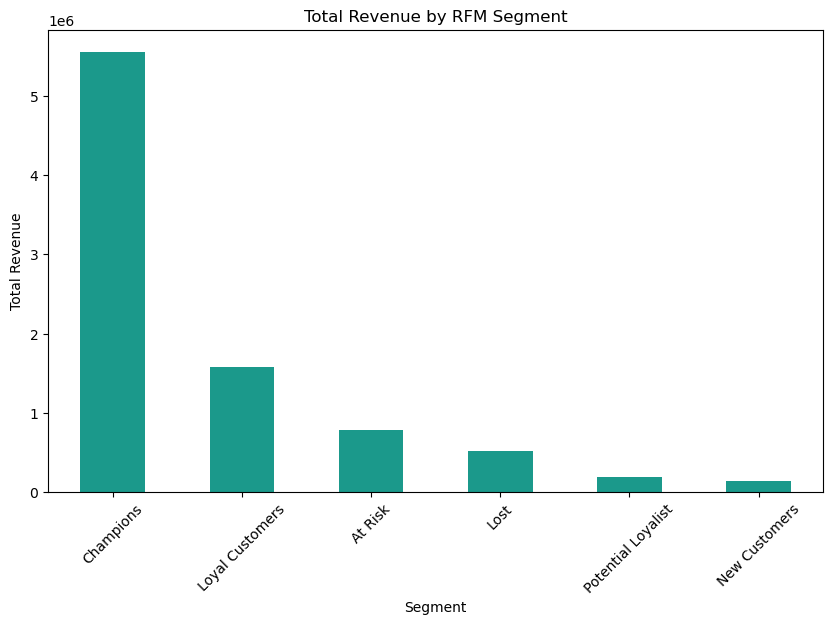

In [43]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
segment_revenue.plot(kind='bar', color='#1B998B')
plt.title('Total Revenue by RFM Segment')
plt.xlabel('Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [44]:
# Remove any leftover Segment columns from previous attempts
cols_to_drop = [col for col in df_clean.columns if col.startswith('Segment')]
df_clean = df_clean.drop(columns=cols_to_drop)

print(df_clean.columns.tolist())  # confirm no Segment columns remain

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalRevenue', 'PurchaseHour', 'DayOfWeek', 'YearMonth']


In [45]:
rfm_reset = rfm.reset_index()
rfm_reset['CustomerID'] = rfm_reset['CustomerID'].astype(str)
df_clean['CustomerID'] = df_clean['CustomerID'].astype(str)

df_clean = df_clean.merge(rfm_reset[['CustomerID', 'Segment']], on='CustomerID', how='left')
df_clean['Segment'] = df_clean['Segment'].fillna('Guest')

print(df_clean['Segment'].value_counts())

Segment
Champions             223163
Guest                 131455
Loyal Customers        88412
At Risk                37888
Lost                   23087
Potential Loyalist     13526
New Customers          10264
Name: count, dtype: int64


In [46]:
champions_top_products = df_clean[df_clean['Segment']=='Champions'].groupby('Description')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
print(champions_top_products)

Description
REGENCY CAKESTAND 3 TIER              103413.75
WHITE HANGING HEART T-LIGHT HOLDER     65440.60
JUMBO BAG RED RETROSPOT                59757.72
PARTY BUNTING                          42528.08
ASSORTED COLOUR BIRD ORNAMENT          38251.44
CHILLI LIGHTS                          36600.20
RABBIT NIGHT LIGHT                     36236.23
BLACK RECORD COVER FRAME               31568.75
WOOD BLACK BOARD ANT WHITE FINISH      29800.31
PAPER CHAIN KIT 50'S CHRISTMAS         29205.03
Name: TotalRevenue, dtype: float64


In [47]:
print("=== KEY PROJECT METRICS ===")
print(f"Total unique customers: {rfm.shape[0]}")
print(f"Total revenue analyzed: ${df_clean['TotalRevenue'].sum():,.2f}")
print(f"Champions: {(rfm['Segment']=='Champions').sum()} customers ({(rfm['Segment']=='Champions').sum()/len(rfm)*100:.1f}%)")
print(f"Champions revenue share: {champions_revenue/total_revenue*100:.1f}%")
print(f"Peak sales hour: 12 PM")
print(f"Highest volume day: Thursday")
print(f"Zero-order day: Saturday")
print(f"Peak revenue month: November 2011")

=== KEY PROJECT METRICS ===
Total unique customers: 4334
Total revenue analyzed: $10,272,184.47
Champions: 839 customers (19.4%)
Champions revenue share: 63.5%
Peak sales hour: 12 PM
Highest volume day: Thursday
Zero-order day: Saturday
Peak revenue month: November 2011


## Key Findings

- **4,334 unique customers** generated **$10.27M** in total revenue
- **Champions (19.4% of customers) drive 63.5% of total revenue** — a strong Pareto effect
- Peak order volume occurs at **12 PM**, with **Thursday** as the busiest day
- **Saturday shows zero orders**, suggesting a B2B/wholesale operation with no weekend processing
- Revenue peaks sharply in **November**, consistent with holiday shopping demand
- Champions' top products largely mirror overall best-sellers — loyalty isn't driven by unique taste, but by repeat purchasing of core catalog items